# 03 - Budowanie akcji ofensywnych

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from mgr_mk.data_loader import load_events, load_world_cup_2018_matches, team_name
from mgr_mk.datasets import build_player_match_dataset
from mgr_mk.mvp import add_player_momentum_to_dataset, score_mvp_candidates, select_match_mvps
from mgr_mk.offensive_actions import build_offensive_sequences, build_player_offensive_features


## Wybór meczu

In [3]:
MATCH_ID = 8650

matches = load_world_cup_2018_matches()
match_info = matches.loc[matches['match_id'].eq(MATCH_ID)].iloc[0]
events = load_events(MATCH_ID)

home_team = team_name(match_info, 'home_team')
away_team = team_name(match_info, 'away_team')
print(f"{MATCH_ID}: {home_team} {match_info['home_score']} - {match_info['away_score']} {away_team}")
print(f"Liczba eventów: {len(events)}")


8650: Brazil 1 - 2 Belgium
Liczba eventów: 3589


## Sekwencje ofensywne

In [4]:
sequences = build_offensive_sequences(events, MATCH_ID)
sequences.head(10)


,match_id,possession,team.name,start_minute,end_minute,event_count,player_count,involved_players,shot_count,sequence_xg,ends_with_shot
0,8650,1,Brazil,0,0,2,0,[],0,0.0,False
1,8650,2,Brazil,0,0,37,7,"[Fernando Luiz Roza, Fágner Conserva Lemos, Jo...",0,0.0,False
2,8650,3,Belgium,0,1,14,4,"[Jan Vertonghen, Romelu Lukaku Menama, Toby Al...",0,0.0,False
3,8650,4,Brazil,1,2,23,6,"[Alisson Ramsés Becker, Fernando Luiz Roza, Fá...",0,0.0,False
4,8650,5,Belgium,2,2,28,6,"[Jan Vertonghen, Marouane Fellaini-Bakkioui, R...",0,0.0,False
5,8650,6,Belgium,2,2,6,2,"[Axel Witsel, Thomas Meunier]",0,0.0,False
6,8650,7,Brazil,2,2,9,2,"[Gabriel Fernando de Jesus, Neymar da Silva Sa...",0,0.0,False
7,8650,8,Belgium,2,3,15,5,"[Axel Witsel, Eden Hazard, Jan Vertonghen, Kev...",0,0.0,False
8,8650,9,Belgium,3,3,15,4,"[Jan Vertonghen, Marouane Fellaini-Bakkioui, T...",0,0.0,False
9,8650,10,Brazil,3,4,24,7,"[Fernando Luiz Roza, Fágner Conserva Lemos, Jo...",0,0.0,False


In [5]:
sequence_summary = (
    sequences.groupby('team.name')
    .agg(
        possessions=('possession', 'count'),
        shot_sequences=('ends_with_shot', 'sum'),
        shots=('shot_count', 'sum'),
        sequence_xg=('sequence_xg', 'sum'),
        avg_events=('event_count', 'mean'),
    )
    .sort_values('sequence_xg', ascending=False)
)
sequence_summary


,possessions,shot_sequences,shots,sequence_xg,avg_events
team.name,,,,,
Brazil,90,23,25,2.609196,18.411111
Belgium,83,6,7,0.384795,13.602410


## Cechy zawodników budujących atak

Najważniejsze pola: `progressive_actions`, `final_third_entries`, `box_entries`, `xg_chain`, `xg_buildup`. `xg_chain` daje udział wszystkim zawodnikom z akcji zakończonej strzałem, a `xg_buildup` wyklucza strzelca i bezpośredniego asystenta, żeby wyróżnić wcześniejsze budowanie akcji.

In [6]:
offensive_features = build_player_offensive_features(events, MATCH_ID)
offensive_features.sort_values(
    ['xg_chain', 'progressive_actions', 'box_entries'],
    ascending=False,
).head(15)


,match_id,player.id,player.name,team.name,offensive_sequence_involvements,shot_ending_sequence_involvements,progressive_passes,progressive_carries,final_third_entries,box_entries,passes_into_box,carries_into_box,shot_assists,xg_chain,xg_buildup,offensive_sequences_xg,progressive_actions
15,8650,4320.0,Neymar da Silva Santos Junior,Brazil,62,19,4,15,8,14,7,7,8,2.422834,1.007108,2.422834,19
11,8650,3501.0,Philippe Coutinho Correia,Brazil,57,14,7,11,14,3,2,1,2,1.516476,0.807044,1.516476,18
8,8650,3295.0,Thiago Emiliano da Silva,Brazil,41,11,2,4,5,0,0,0,1,1.452875,1.172156,1.452875,6
20,8650,5552.0,Marcelo Vieira da Silva Júnior,Brazil,58,14,17,6,13,8,7,1,3,1.338844,1.020965,1.338844,23
1,8650,3054.0,Fernando Luiz Roza,Brazil,44,12,2,1,6,0,0,0,2,1.088902,0.930858,1.088902,3
13,8650,3535.0,Roberto Firmino Barbosa de Oliveira,Brazil,23,8,2,0,1,0,0,0,1,1.007646,0.494538,1.007646,2
10,8650,3472.0,Willian Borges da Silva,Brazil,20,6,0,3,1,1,1,0,1,0.989192,0.785480,0.989192,3
17,8650,5542.0,José Paulo Bezzera Maciel Júnior,Brazil,30,6,1,1,1,0,0,0,0,0.950215,0.536441,0.950215,2
6,8650,3202.0,Gabriel Fernando de Jesus,Brazil,14,4,0,0,0,2,0,2,1,0.734617,0.035846,0.734617,0
24,8650,5838.0,Fágner Conserva Lemos,Brazil,31,6,1,0,3,2,2,0,1,0.714450,0.678604,0.714450,1


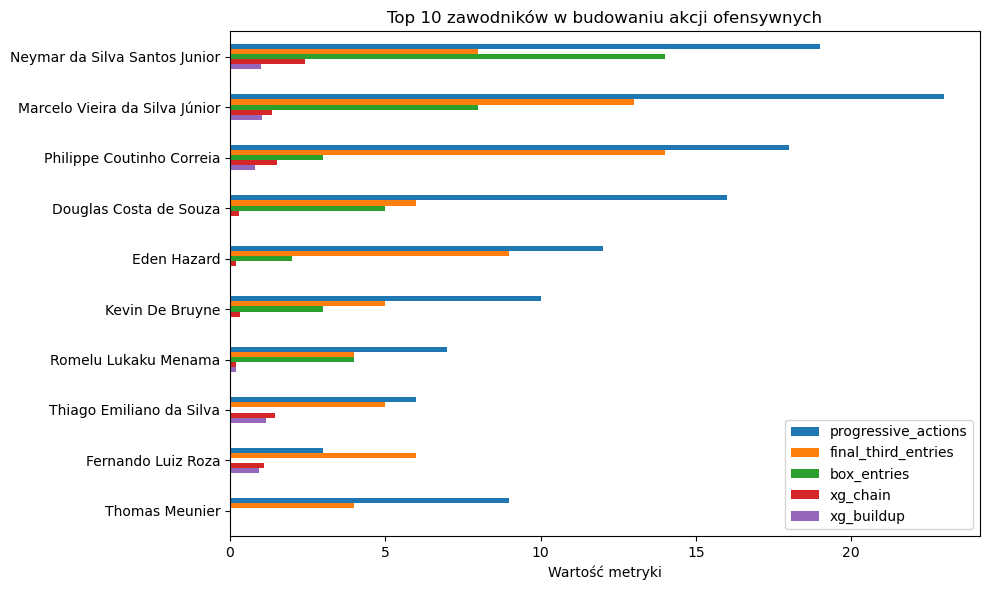

In [7]:
plot_cols = ['progressive_actions', 'final_third_entries', 'box_entries', 'xg_chain', 'xg_buildup']
top_offensive = (
    offensive_features.assign(
        offensive_building_score=(
            offensive_features['progressive_actions']
            + 2 * offensive_features['final_third_entries']
            + 3 * offensive_features['box_entries']
            + 5 * offensive_features['xg_chain']
        )
    )
    .sort_values('offensive_building_score', ascending=False)
    .head(10)
)

ax = top_offensive.set_index('player.name')[plot_cols].plot(kind='barh', figsize=(10, 6))
ax.invert_yaxis()
ax.set_title('Top 10 zawodników w budowaniu akcji ofensywnych')
ax.set_xlabel('Wartość metryki')
ax.set_ylabel('')
plt.tight_layout()


## Wpływ na MVP

In [8]:
dataset = build_player_match_dataset(matches, match_ids=[MATCH_ID])
dataset = add_player_momentum_to_dataset(dataset, matches)
scored = score_mvp_candidates(dataset)
mvp = select_match_mvps(scored)

ranking_columns = [
    'player.name',
    'team.name',
    'minutes_played',
    'mvp_score',
    'attacking_component',
    'offensive_building_component',
    'involvement_component',
    'defending_component',
    'player_momentum',
    'xg_chain_per90',
    'xg_buildup_per90',
    'progressive_actions_per90',
]

scored.sort_values('mvp_score', ascending=False)[ranking_columns].head(15)


,player.name,team.name,minutes_played,mvp_score,attacking_component,offensive_building_component,involvement_component,defending_component,player_momentum,xg_chain_per90,xg_buildup_per90,progressive_actions_per90
11,Philippe Coutinho Correia,Brazil,95.0,0.650599,0.784536,0.653314,0.938746,0.382892,12.724406,1.436662,0.764568,17.052632
3,Kevin De Bruyne,Belgium,95.0,0.577796,0.306024,0.226364,0.642207,0.249867,20.754409,0.310585,0.000000,9.473684
15,Neymar da Silva Santos Junior,Brazil,94.0,0.540888,0.545568,0.858981,0.836616,0.099086,8.618396,2.319735,0.964253,18.191489
20,Marcelo Vieira da Silva Júnior,Brazil,95.0,0.489348,0.336198,0.749778,0.908466,0.466895,6.170518,1.268379,0.967230,21.789474
14,Eden Hazard,Belgium,95.0,0.414888,0.391354,0.240576,0.647286,0.104706,9.058533,0.188839,0.000000,11.368421
23,Douglas Costa de Souza,Brazil,37.0,0.406585,0.554751,0.498323,0.428515,0.308586,6.975834,0.739400,0.115689,38.918919
21,Renato Soares de Oliveira Augusto,Brazil,20.0,0.400019,0.460587,0.115496,0.197036,0.033157,17.428912,1.674141,0.000000,4.500000
17,José Paulo Bezzera Maciel Júnior,Brazil,72.0,0.393143,0.605969,0.281974,0.686112,0.196556,6.432642,1.187769,0.670552,2.500000
8,Thiago Emiliano da Silva,Brazil,93.0,0.378974,0.390813,0.460133,0.757583,0.215131,5.094126,1.406008,1.134345,5.806452
1,Fernando Luiz Roza,Brazil,96.0,0.361202,0.246201,0.390077,0.781928,0.524200,4.443991,1.020845,0.872680,2.812500


In [9]:
mvp
#Kevin De Bruyne


,match_id,match_date,competition_stage,player.name,team.name,opponent,result,minutes_played,player_momentum,mvp_score,mvp_rank_all_players,mvp_rank_eligible,is_mvp_eligible
0,8650,2018-07-06,Quarter-finals,Philippe Coutinho Correia,Brazil,Belgium,loss,95.0,12.724406,0.650599,1.0,1.0,True


## Pętla po wielu meczach

In [10]:
N_MATCHES = 10
MATCH_IDS = matches['match_id'].head(N_MATCHES).astype(int).tolist()

all_rows = []
for match_id in MATCH_IDS:
    events_loop = load_events(match_id)
    features_loop = build_player_offensive_features(events_loop, match_id)
    best_players = (
        features_loop.assign(
            offensive_building_score=(
                features_loop['progressive_actions']
                + 2 * features_loop['final_third_entries']
                + 3 * features_loop['box_entries']
                + 5 * features_loop['xg_chain']
            )
        )
        .sort_values('offensive_building_score', ascending=False)
        .head(5)
    )
    all_rows.append(best_players)

multi_match_offensive = pd.concat(all_rows, ignore_index=True)
multi_match_offensive[['match_id', 'player.name', 'team.name', 'progressive_actions', 'final_third_entries', 'box_entries', 'xg_chain', 'xg_buildup', 'offensive_building_score']].head(30)


,match_id,player.name,team.name,progressive_actions,final_third_entries,box_entries,xg_chain,xg_buildup,offensive_building_score
0,8650,Neymar da Silva Santos Junior,Brazil,19,8,14,2.422834,1.007108,89.114172
1,8650,Marcelo Vieira da Silva Júnior,Brazil,23,13,8,1.338844,1.020965,79.694221
2,8650,Philippe Coutinho Correia,Brazil,18,14,3,1.516476,0.807044,62.582382
3,8650,Douglas Costa de Souza,Brazil,16,6,5,0.303976,0.047561,44.519878
4,8650,Eden Hazard,Belgium,12,9,2,0.199330,0.000000,36.996651
5,7584,Thomas Meunier,Belgium,25,11,9,2.115430,1.043482,84.577152
6,7584,Kevin De Bruyne,Belgium,12,10,10,2.021170,1.192602,72.105850
7,7584,Eden Hazard,Belgium,13,6,10,1.664664,0.910738,63.323320
8,7584,Toby Alderweireld,Belgium,12,12,0,0.908814,0.908814,40.544069
9,7584,Axel Witsel,Belgium,6,8,0,1.555128,1.354932,29.775640


## MVP dla wszystkich meczów

Ta komórka przelicza ranking MVP dla wielu meczów i zwraca DataFrame `all_match_mvps`.

In [11]:
MVP_MATCH_IDS = None

mvp_dataset = build_player_match_dataset(matches, match_ids=MVP_MATCH_IDS) #+ ofensywne akcje
mvp_dataset = add_player_momentum_to_dataset(mvp_dataset, matches)
mvp_candidates = score_mvp_candidates(mvp_dataset)
all_match_mvps = select_match_mvps(mvp_candidates)

all_match_mvps = all_match_mvps.sort_values(
    ['match_date', 'match_id'],
    ascending=True,
).reset_index(drop=True)

display(all_match_mvps)
all_match_mvps

#finał: Antoine Griezmann
#3 miejsce: Eden Hazard
#Semifinal: (Samuel Umtiti),(Ivan Perisic)
#Quarterfinal Uruguay 0-2 France (Antoine Griezmann) Brazil 1-2 Belgium (Kevin de Bruyne) England 2-0 Sweden (Jordan Pickford) Russia 2-2 Croatia (3-4 pens) Luka Modric


,match_id,match_date,competition_stage,player.name,team.name,opponent,result,minutes_played,player_momentum,mvp_score,mvp_rank_all_players,mvp_rank_eligible,is_mvp_eligible
0,7525,2018-06-14,Group Stage,Denis Cheryshev,Russia,Saudi Arabia,win,67.0,34.914470,0.708013,1.0,1.0,True
1,7576,2018-06-15,Group Stage,Cristiano Ronaldo dos Santos Aveiro,Portugal,Spain,draw,94.0,50.438138,0.649453,1.0,1.0,True
2,7577,2018-06-15,Group Stage,Hakim Ziyech,Morocco,Iran,loss,93.0,7.510260,0.748597,1.0,1.0,True
3,7578,2018-06-15,Group Stage,José María Giménez de Vargas,Uruguay,Egypt,win,95.0,19.437496,0.707248,1.0,1.0,True
4,7529,2018-06-16,Group Stage,Luka Modrić,Croatia,Nigeria,win,93.0,19.000000,0.867856,1.0,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,8652,2018-07-07,Quarter-finals,Luka Modrić,Croatia,Russia,draw,126.0,30.457108,0.796422,1.0,1.0,True
60,8655,2018-07-10,Semi-finals,Olivier Giroud,France,Belgium,win,83.0,13.336198,0.653052,1.0,1.0,True
61,8656,2018-07-11,Semi-finals,Ivan Perišić,Croatia,England,win,124.0,25.635289,0.716277,1.0,1.0,True
62,8657,2018-07-14,3rd Place Final,Eden Hazard,Belgium,England,win,92.0,21.940246,0.770667,1.0,1.0,True


,match_id,match_date,competition_stage,player.name,team.name,opponent,result,minutes_played,player_momentum,mvp_score,mvp_rank_all_players,mvp_rank_eligible,is_mvp_eligible
0,7525,2018-06-14,Group Stage,Denis Cheryshev,Russia,Saudi Arabia,win,67.0,34.914470,0.708013,1.0,1.0,True
1,7576,2018-06-15,Group Stage,Cristiano Ronaldo dos Santos Aveiro,Portugal,Spain,draw,94.0,50.438138,0.649453,1.0,1.0,True
2,7577,2018-06-15,Group Stage,Hakim Ziyech,Morocco,Iran,loss,93.0,7.510260,0.748597,1.0,1.0,True
3,7578,2018-06-15,Group Stage,José María Giménez de Vargas,Uruguay,Egypt,win,95.0,19.437496,0.707248,1.0,1.0,True
4,7529,2018-06-16,Group Stage,Luka Modrić,Croatia,Nigeria,win,93.0,19.000000,0.867856,1.0,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,8652,2018-07-07,Quarter-finals,Luka Modrić,Croatia,Russia,draw,126.0,30.457108,0.796422,1.0,1.0,True
60,8655,2018-07-10,Semi-finals,Olivier Giroud,France,Belgium,win,83.0,13.336198,0.653052,1.0,1.0,True
61,8656,2018-07-11,Semi-finals,Ivan Perišić,Croatia,England,win,124.0,25.635289,0.716277,1.0,1.0,True
62,8657,2018-07-14,3rd Place Final,Eden Hazard,Belgium,England,win,92.0,21.940246,0.770667,1.0,1.0,True


In [12]:
all_match_mvps.tail(10)
#finał: Antoine Griezmann
#3 miejsce: Eden Hazard
#Semifinal: (Samuel Umtiti),(Ivan Perisic)
#Quarterfinal Uruguay 0-2 France (Antoine Griezmann) Brazil 1-2 Belgium (Kevin de Bruyne) England 2-0 Sweden (Jordan Pickford) Russia 2-2 Croatia (3-4 pens) Luka Modric


,match_id,match_date,competition_stage,player.name,team.name,opponent,result,minutes_played,player_momentum,mvp_score,mvp_rank_all_players,mvp_rank_eligible,is_mvp_eligible
54,7585,2018-07-03,Round of 16,Harry Kane,England,Colombia,draw,122.0,38.449190,0.699725,1.0,1.0,True
55,7586,2018-07-03,Round of 16,Emil Peter Forsberg,Sweden,Switzerland,win,81.0,18.726715,0.707450,1.0,1.0,True
56,8649,2018-07-06,Quarter-finals,Antoine Griezmann,France,Uruguay,win,93.0,18.045260,0.717636,1.0,1.0,True
57,8650,2018-07-06,Quarter-finals,Philippe Coutinho Correia,Brazil,Belgium,loss,95.0,12.724406,0.650599,1.0,1.0,True
58,8651,2018-07-07,Quarter-finals,Bamidele Alli,England,Sweden,win,76.0,20.085823,0.704248,1.0,1.0,True
59,8652,2018-07-07,Quarter-finals,Luka Modrić,Croatia,Russia,draw,126.0,30.457108,0.796422,1.0,1.0,True
60,8655,2018-07-10,Semi-finals,Olivier Giroud,France,Belgium,win,83.0,13.336198,0.653052,1.0,1.0,True
61,8656,2018-07-11,Semi-finals,Ivan Perišić,Croatia,England,win,124.0,25.635289,0.716277,1.0,1.0,True
62,8657,2018-07-14,3rd Place Final,Eden Hazard,Belgium,England,win,92.0,21.940246,0.770667,1.0,1.0,True
63,8658,2018-07-15,Final,Paul Pogba,France,Croatia,win,94.0,19.913498,0.650903,1.0,1.0,True


## Top 3 MVP dla każdego meczu

Ta tabela pokazuje trzech najwyżej ocenionych zawodników w każdym meczu. Dzięki kolumnom z komponentami można szybko zobaczyć, czy wynik zawodnika wynika bardziej z momentum, ataku, budowania akcji ofensywnych, zaangażowania czy defensywy.

In [13]:

try:
    mvp_candidates
except NameError:
    MVP_MATCH_IDS = None
    mvp_dataset = build_player_match_dataset(matches, match_ids=MVP_MATCH_IDS)
    mvp_dataset = add_player_momentum_to_dataset(mvp_dataset, matches)
    mvp_candidates = score_mvp_candidates(mvp_dataset)

top_3_mvps_by_match = (
    mvp_candidates[mvp_candidates['is_mvp_eligible']]
    .sort_values(['match_id', 'mvp_score'], ascending=[True, False])
    .groupby('match_id', as_index=False)
    .head(3)
    .copy()
)

top_3_mvps_by_match['mvp_position'] = (
    top_3_mvps_by_match.groupby('match_id')['mvp_score']
    .rank(ascending=False, method='first')
    .astype(int)
)

top_3_mvps_by_match = top_3_mvps_by_match.sort_values(
    ['match_date', 'match_id', 'mvp_position']
).reset_index(drop=True)

readable_top_3_mvps = top_3_mvps_by_match[
    [
        'match_id',
        'mvp_position',
        'player.name',
        'mvp_score',
    ]
].rename(
    columns={
        'player.name': 'player',
        'mvp_position': 'top3_position',
    }
)

readable_top_3_mvps['mvp_score'] = readable_top_3_mvps['mvp_score'].round(4)

readable_top_3_mvps


,match_id,top3_position,player,mvp_score
0,7525,1,Denis Cheryshev,0.7080
1,7525,2,Aleksandr Golovin,0.5878
2,7525,3,Aleksandr Samedov,0.4481
3,7576,1,Cristiano Ronaldo dos Santos Aveiro,0.6495
4,7576,2,Diego da Silva Costa,0.5153
...,...,...,...,...
187,8657,2,Eric Dier,0.6257
188,8657,3,Thomas Meunier,0.5722
189,8658,1,Paul Pogba,0.6509
190,8658,2,Antoine Griezmann,0.6134


## Wizualizacja top 3 MVP w fazie pucharowej


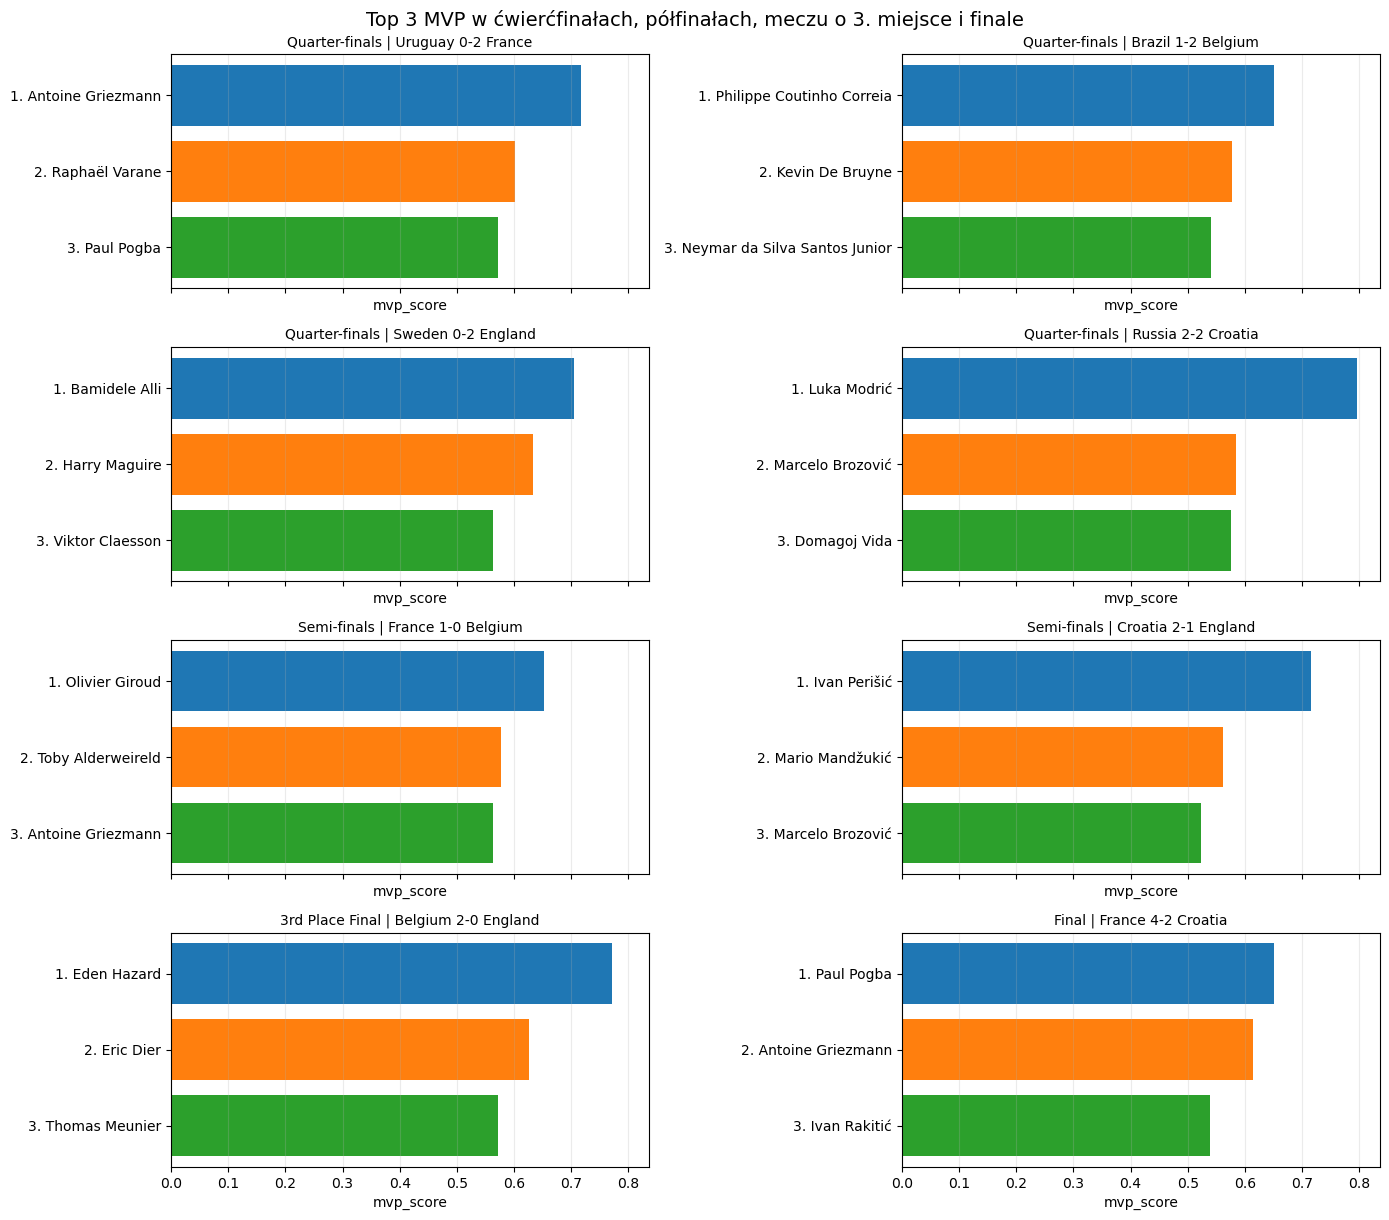

,match_id,stage,home_team,away_team,top3_position,player,team,mvp_score
0,8649,Quarter-finals,Uruguay,France,1,Antoine Griezmann,France,0.7176
1,8649,Quarter-finals,Uruguay,France,2,Raphaël Varane,France,0.6015
2,8649,Quarter-finals,Uruguay,France,3,Paul Pogba,France,0.5725
3,8650,Quarter-finals,Brazil,Belgium,1,Philippe Coutinho Correia,Brazil,0.6506
4,8650,Quarter-finals,Brazil,Belgium,2,Kevin De Bruyne,Belgium,0.5778
5,8650,Quarter-finals,Brazil,Belgium,3,Neymar da Silva Santos Junior,Brazil,0.5409
6,8651,Quarter-finals,Sweden,England,1,Bamidele Alli,England,0.7042
7,8651,Quarter-finals,Sweden,England,2,Harry Maguire,England,0.6337
8,8651,Quarter-finals,Sweden,England,3,Viktor Claesson,Sweden,0.5633
9,8652,Quarter-finals,Russia,Croatia,1,Luka Modrić,Croatia,0.7964


In [15]:

try:
    mvp_candidates
except NameError:
    MVP_MATCH_IDS = None
    mvp_dataset = build_player_match_dataset(matches, match_ids=MVP_MATCH_IDS)
    mvp_dataset = add_player_momentum_to_dataset(mvp_dataset, matches)
    mvp_candidates = score_mvp_candidates(mvp_dataset)

key_stages = ['Quarter-finals', 'Semi-finals', '3rd Place Final', 'Final']
stage_order = {stage: index for index, stage in enumerate(key_stages)}

key_stage_top3 = (
    mvp_candidates[
        mvp_candidates['is_mvp_eligible']
        & mvp_candidates['competition_stage'].isin(key_stages)
    ]
    .sort_values(['match_id', 'mvp_score'], ascending=[True, False])
    .groupby('match_id', as_index=False)
    .head(3)
    .copy()
)

key_stage_top3['top3_position'] = (
    key_stage_top3.groupby('match_id')['mvp_score']
    .rank(ascending=False, method='first')
    .astype(int)
)
key_stage_top3['stage_order'] = key_stage_top3['competition_stage'].map(stage_order)
key_stage_top3['match_label'] = (
    key_stage_top3['competition_stage']
    + ' | '
    + key_stage_top3['home_team']
    + ' '
    + key_stage_top3['home_score'].astype(str)
    + '-'
    + key_stage_top3['away_score'].astype(str)
    + ' '
    + key_stage_top3['away_team']
)

key_stage_top3 = key_stage_top3.sort_values(
    ['stage_order', 'match_date', 'match_id', 'top3_position']
).reset_index(drop=True)

match_labels = key_stage_top3[['match_id', 'match_label']].drop_duplicates()
n_matches = len(match_labels)
n_cols = 2
n_rows = (n_matches + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.1 * n_rows), sharex=True)
axes = axes.flatten() if n_matches > 1 else [axes]
colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c'}

for ax, (_, match_row) in zip(axes, match_labels.iterrows()):
    match_rows = key_stage_top3[key_stage_top3['match_id'].eq(match_row['match_id'])]
    match_rows = match_rows.sort_values('top3_position', ascending=False)
    labels = match_rows['top3_position'].astype(str) + '. ' + match_rows['player.name']
    ax.barh(
        labels,
        match_rows['mvp_score'],
        color=[colors[position] for position in match_rows['top3_position']],
    )
    ax.set_title(match_row['match_label'], fontsize=10)
    ax.set_xlabel('mvp_score')
    ax.grid(axis='x', alpha=0.25)

for ax in axes[n_matches:]:
    ax.axis('off')

fig.suptitle('Top 3 MVP w ćwierćfinałach, półfinałach, meczu o 3. miejsce i finale', fontsize=14)
plt.tight_layout()
plt.show()

key_stage_top3_table = key_stage_top3[
    ['match_id', 'competition_stage', 'home_team', 'away_team', 'top3_position', 'player.name', 'team.name', 'mvp_score']
].rename(
    columns={
        'competition_stage': 'stage',
        'player.name': 'player',
        'team.name': 'team',
    }
)
key_stage_top3_table['mvp_score'] = key_stage_top3_table['mvp_score'].round(4)
key_stage_top3_table
